# 00 -- Dataset exploration: what are we actually classifying?

This is lesson 1 of a passive-sonar signal analysis lab. The dataset is
the Watkins Marine Mammal Sound Database -- but treat every clip the way
a sonar operator would treat a hydrophone contact: an acoustic signature
you need to detect, characterize, and classify, not just "a whale sound."
Several of the species in this database are themselves biological sonar
systems (dolphins and sperm whales navigate and hunt by echolocation --
literal biosonar), which makes this a more direct fit for sonar-analysis
methods than it might first look.

Before touching a single model, get intimate with the data: listen to it,
look at it, and -- most importantly -- **stress-test the assumptions any
model trained on this data implicitly makes**, because two of them matter
a lot:

1. How severely imbalanced are the 54 species, and what does that imply
   for evaluation?
2. Does a naive train/test split actually test whether a model recognizes
   a *species*, or does it let the model partly recognize a specific
   *recording* instead (spoiler: it's the latter unless you're careful,
   and you're about to see why).

Everything here is powered by `watkins.data`, the package built for this
project (see `src/watkins/`).

In [1]:
import os
import subprocess
import sys
import importlib.util

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1. Mount Drive and locate the project. Upload src/, configs/,
    #    pyproject.toml, requirements.txt to this path in My Drive first --
    #    NOT the multi-GB Watkins/ or results/ folders, those are handled
    #    separately below.
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_DRIVE_PATH = "/content/drive/MyDrive/ShipsEAR"  # <-- edit if you used a different path
    if not os.path.exists(f"{PROJECT_DRIVE_PATH}/src/watkins"):
        raise FileNotFoundError(
            f"Expected the project's src/ folder at {PROJECT_DRIVE_PATH}/src on Google Drive.\n"
            "Upload src/, configs/, pyproject.toml, and requirements.txt there "
            "(skip the multi-GB Watkins/ and results/ folders), or edit "
            "PROJECT_DRIVE_PATH above to match where you put them."
        )
    sys.path.insert(0, f"{PROJECT_DRIVE_PATH}/src")

    # 2. Install whatever Colab's base image doesn't already have. Deliberately
    #    does NOT touch torch/torchaudio/torchvision -- Colab's preinstalled
    #    versions are already matched to its GPU + CUDA build, and reinstalling
    #    this project's CPU-only wheels here would silently disable the GPU.
    needed = ["transformers", "timm", "soundfile", "datasets", "huggingface_hub", "pyarrow"]
    missing = [pkg for pkg in needed if importlib.util.find_spec(pkg) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

    # 3. Data goes on fast local/ephemeral disk (re-derivable from the public
    #    Hugging Face source, no reason to pay Drive's slow random-I/O tax on
    #    thousands of per-epoch file reads); results go on Drive so trained
    #    checkpoints/metrics survive a runtime disconnect.
    os.environ["WATKINS_DATA_ROOT"] = "/content/watkins_data"
    os.environ["WATKINS_RESULTS_ROOT"] = f"{PROJECT_DRIVE_PATH}/results"

    from watkins.data import DATA_ROOT
    if not (DATA_ROOT / "manifest.csv").exists():
        print("Materializing the Watkins dataset locally -- one-time per Colab runtime, ~10-15 min...")
        subprocess.run([sys.executable, "-m", "watkins.prepare_data"], check=True)
else:
    sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import IPython.display as ipd

from watkins.data import load_manifest, get_split, CLASS_INFO, CLASS_IDS, DATA_ROOT, NUM_CLASSES


## 1. How many clips, how many species, how imbalanced?

Run the cell below. You should see 15,248 clips across 54 species, and a
distribution spanning **three orders of magnitude** -- killer whale alone
accounts for over 2,600 clips, while several species have a single-digit
clip count. This is a real property of a ~70-year historical archive
built opportunistically (some species, and some individual animals, were
simply recorded far more often), not a preprocessing artifact. Keep this
in mind for every model trained in this project: accuracy alone will
flatter a model that just leans on killer whale and sperm whale.
That's why `watkins.train` uses class-weighted loss by default and every
evaluation in this project reports per-class precision/recall/F1, not
just accuracy.

total clips: 15248
total species: 54


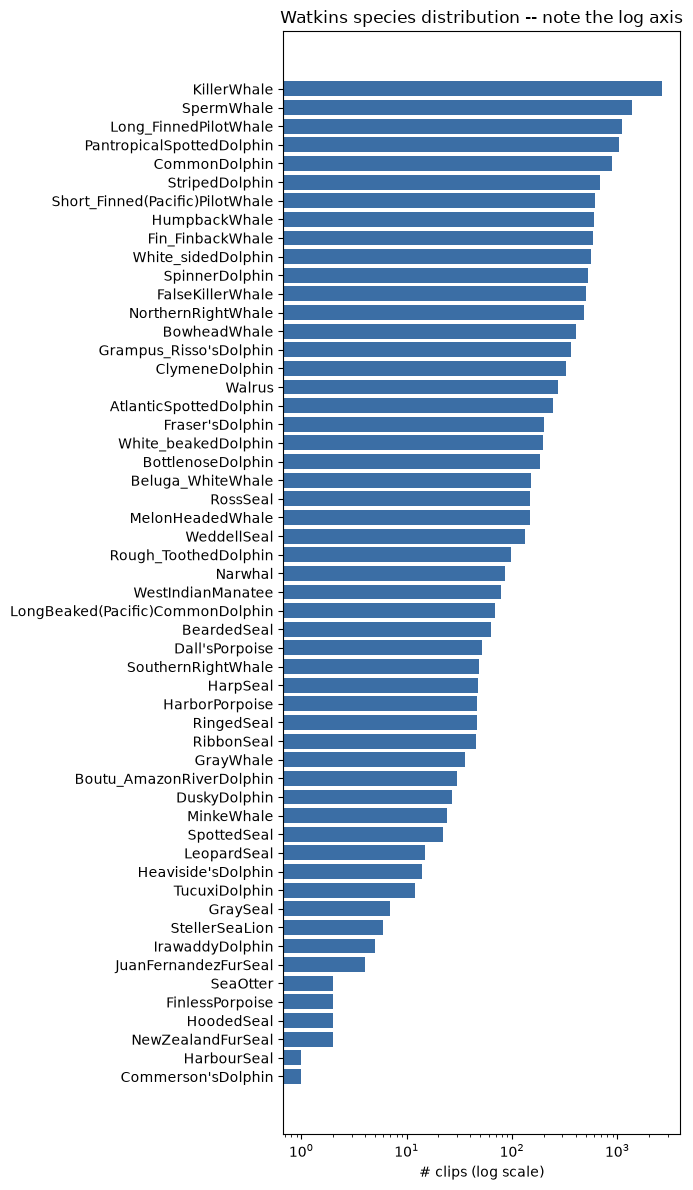

5 most-represented species: [('KillerWhale', 2647), ('SpermWhale', 1379), ('Long_FinnedPilotWhale', 1104), ('PantropicalSpottedDolphin', 1025), ('CommonDolphin', 884)]
5 least-represented species: [('FinlessPorpoise', 2), ('HoodedSeal', 2), ('NewZealandFurSeal', 2), ('HarbourSeal', 1), ("Commerson'sDolphin", 1)]


In [2]:
manifest = load_manifest()
print(f"total clips: {len(manifest)}")
print(f"total species: {NUM_CLASSES}")

counts = {c: 0 for c in CLASS_IDS}
for clip in manifest:
    counts[clip.label] += 1

order = sorted(CLASS_IDS, key=lambda c: -counts[c])
names = [CLASS_INFO[c]["display_name"] for c in order]

fig, ax = plt.subplots(figsize=(7, 12))
ax.barh(names, [counts[c] for c in order], color="#3b6ea5")
ax.set_xscale("log")
ax.set_xlabel("# clips (log scale)")
ax.set_title("Watkins species distribution -- note the log axis")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("5 most-represented species:", [(names[i], counts[order[i]]) for i in range(5)])
print("5 least-represented species:", [(names[i], counts[order[i]]) for i in range(-5, 0)])


## 2. Listen: tonal calls vs. biosonar clicks

Some of these species produce sustained tonal calls (baleen whales); some
produce trains of short broadband clicks used for echolocation
(sperm whales, dolphins, porpoises) -- literal active sonar, pointed at
prey and terrain rather than at us. Listening to both kinds back to back
is worth doing before you ever look at a spectrogram: a click train and a
tonal moan are almost nothing alike as raw audio, which is exactly the
kind of distinction a classifier has to learn to make (among 54 species,
not just two).

In [3]:
by_class = {c: [clip for clip in manifest if clip.label == c] for c in CLASS_IDS}

# a tonal baleen whale call, and two echolocating odontocetes (biosonar users)
examples = [12, 51, 14]  # HumpbackWhale, SpermWhale, BottlenoseDolphin
for cid in examples:
    clip = by_class[cid][0]
    print(f"{CLASS_INFO[cid]['display_name']} ({CLASS_INFO[cid]['scientific_name']}) -- {clip.path.name}")
    y, sr = sf.read(clip.path)
    ipd.display(ipd.Audio(y, rate=sr))


HumpbackWhale (Megaptera novaeangliae) -- 52008002.wav


SpermWhale (Physeter catodon) -- 52008001.wav


BottlenoseDolphin (Tursiops truncatus) -- 51041C01.wav


## 3. The leakage trap: why *how* you split the data matters as much as the model

This is the single most important methodology point in this whole
project, and it's easy to miss.

Every clip's `record_number` encodes which original continuous recording
("tape") it was cut from -- `watkins.data.Clip.tape_id` is the first 6
characters of that code. Multiple clips from the same tape sound *very*
similar: same individual animal, same recording equipment, same
background noise floor, often the same distance and aspect to the
hydrophone. If a model sees clips from a tape during training and is then
tested on other clips from *that same tape*, it can partly succeed by
recognizing the recording rather than the species.

`watkins.data.build_split` groups clips by `tape_id` before splitting so
that no split boundary ever cuts through a single tape (`mode=
"tape_grouped"`, the default every model in this project trains on). To
make the risk concrete, this project also ships a deliberately naive
comparison mode, `mode="clip_random"`, that ignores `tape_id` entirely.
Compare what each one does to tape overlap between train and test:

In [4]:
def tape_overlap(split):
    train_tapes = {clip.tape_id for clip in split.train}
    test_tapes = {clip.tape_id for clip in split.test}
    return train_tapes & test_tapes, train_tapes, test_tapes

for mode in ["tape_grouped", "clip_random"]:
    split = get_split(mode=mode)
    overlap, train_tapes, test_tapes = tape_overlap(split)
    print(f"--- {mode} ---")
    print(split.summary())
    print(f"tapes shared between train and test: {len(overlap)} "
          f"(out of {len(train_tapes | test_tapes)} total tapes)")
    print()


--- tape_grouped ---
train=9370  val=2806  test=3072
  14 species have only one source recording and are train-only (excluded from val/test): SeaOtter, TucuxiDolphin, Dall'sPorpoise, StellerSeaLion, Heaviside'sDolphin, JuanFernandezFurSeal, IrawaddyDolphin, FinlessPorpoise, HoodedSeal, HarbourSeal, GraySeal, NewZealandFurSeal, Commerson'sDolphin, DuskyDolphin
tapes shared between train and test: 11 (out of 321 total tapes)



--- clip_random ---
train=10672  val=2286  test=2290
  2 species have only one source recording and are train-only (excluded from val/test): HarbourSeal, Commerson'sDolphin
tapes shared between train and test: 318 (out of 394 total tapes)



`tape_grouped` should show **zero** shared tapes between train and test
by construction. `clip_random` will show a large number -- every one of
those shared tapes means some test clips have a near-duplicate sibling
clip sitting in the training set. Notebook 02 measures exactly how many
accuracy points that inflates a trained model's score by, at full scale.

Also notice `tape_grouped`'s summary lists species with **zero**
val/test clips: those are the species with only one tape total, so
there's nowhere else to draw a held-out set from. `Split.
train_only_classes` names them explicitly rather than hiding the
limitation -- see `docs/class_reference.md` for the full list (14 of 54
species).

## Exercises

1. Listen to 5 clips each from two acoustically similar-sounding dolphin
   species (e.g. `CommonDolphin` and `StripedDolphin`, both fast
   whistle-and-click users). Can you hear a difference at all? If not,
   that's a real signal about how hard this classification problem is
   for *some* species pairs, independent of any model.
2. Pick a species with several tapes (e.g. `Walrus`, 11 tapes -- see
   `docs/class_reference.md`) and plot the waveform envelope
   (`np.abs(y)`, smoothed) for a clip from two *different* tapes. Do the
   noise floors or apparent recording distance differ? That difference is
   exactly what `tape_grouped` splitting protects a model from
   overfitting to.
3. `tape_grouped` still can't give a true held-out recording to the 14
   train-only species. Can you think of a way to partially validate a
   model's performance on those species anyway (hint: what would go wrong
   if you *did* peel off a val/test slice from partway through their one
   tape -- is that better or worse than no evaluation at all)?
4. Sperm whales and many dolphin species produce highly periodic click
   trains for echolocation -- literal biosonar. Keep the
   `SpermWhale`/`BottlenoseDolphin` clips from section 2 in mind: notebook
   01's DEMON analysis section extracts each species' click-repetition
   rate directly from this kind of signal, something a plain spectrogram
   doesn't show as a single clean number.